In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_original = pd.read_csv('Children Recode_final.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis =1)
df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1, inplace=True)
df_original.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10,Malnurished
0,17,1,14,0,1,2,22.00,1,1,2,...,1,0,0,0,0,0,0,0,0,0
1,40,2,17,1,2,2,25.10,2,2,1,...,0,0,0,0,0,0,1,0,0,1
2,59,2,17,1,2,2,25.10,2,2,2,...,0,0,0,0,0,0,1,0,0,1
3,55,2,17,0,2,2,21.53,1,1,2,...,0,0,0,0,0,0,1,0,0,1
4,14,1,16,0,1,2,28.03,1,1,1,...,0,0,0,0,0,0,1,0,0,0


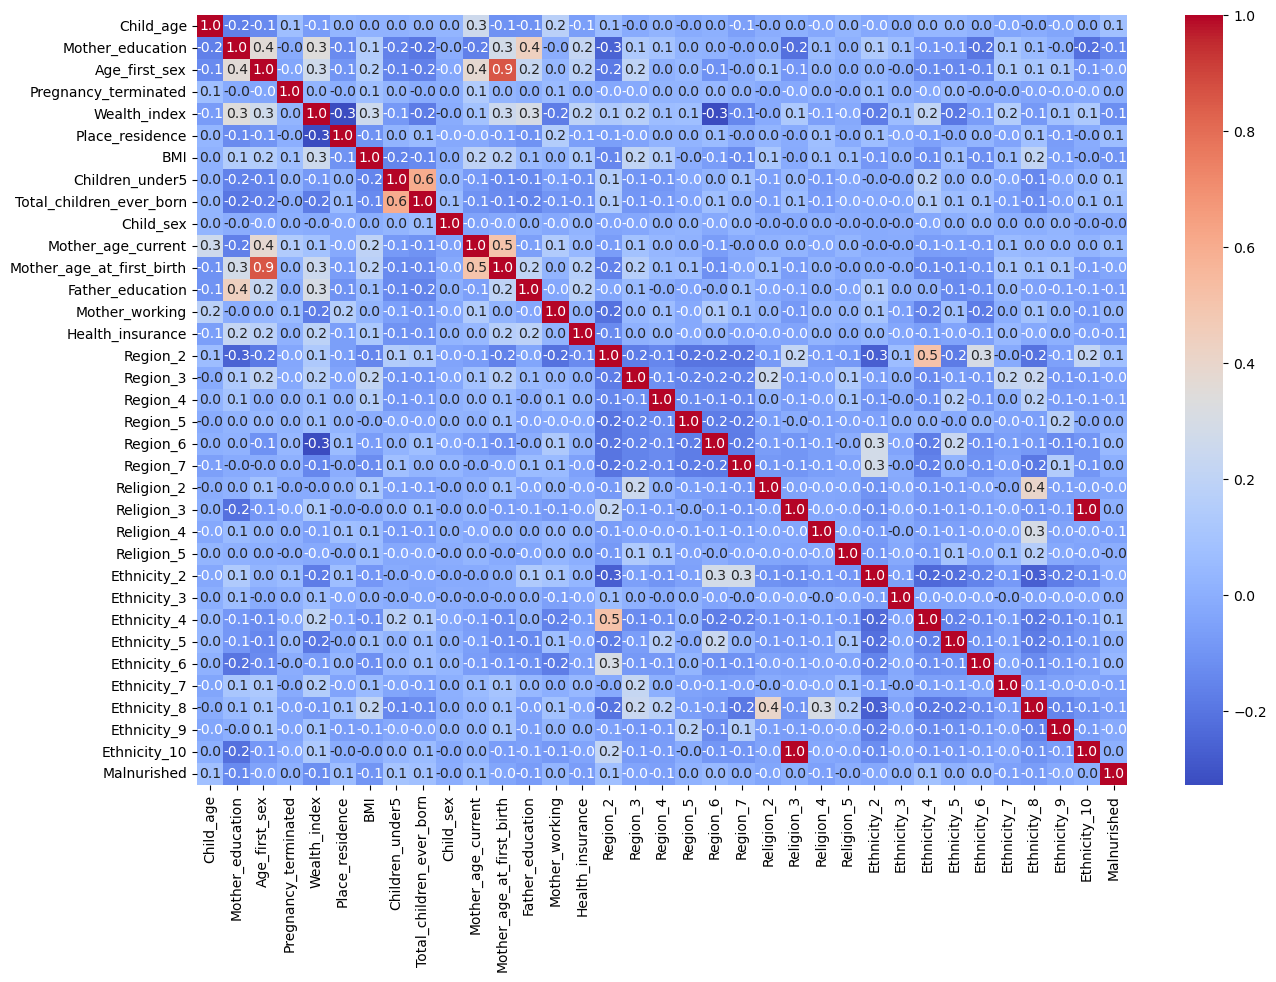

In [40]:
correlation_matrix = df_original.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X = df_original.drop(columns=['Malnurished'])
y = df_original['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = MinMaxScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [5]:
X_train.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
1582,0.915254,2,0.185185,1,1,2,0.210629,2,2,2,...,0,0,0,0,1,0,0,0,0,0
2165,0.966102,1,0.259259,0,5,1,0.414615,2,2,1,...,0,0,0,1,0,0,0,0,0,0
1387,0.084746,2,0.444444,1,5,1,0.451348,0,2,1,...,0,0,0,1,0,0,0,0,0,0
178,1.000000,2,0.333333,0,3,2,0.653380,1,2,2,...,0,0,0,0,1,0,0,0,0,0
478,0.864407,0,0.148148,1,4,1,0.472841,1,1,2,...,0,0,0,0,0,0,0,0,0,1


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
pd.crosstab(y_test, y_pred)

col_0,0,1
Malnurished,,
0,292,14
1,122,20


In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.95      0.81       306
           1       0.59      0.14      0.23       142

    accuracy                           0.70       448
   macro avg       0.65      0.55      0.52       448
weighted avg       0.67      0.70      0.63       448



ROC curve

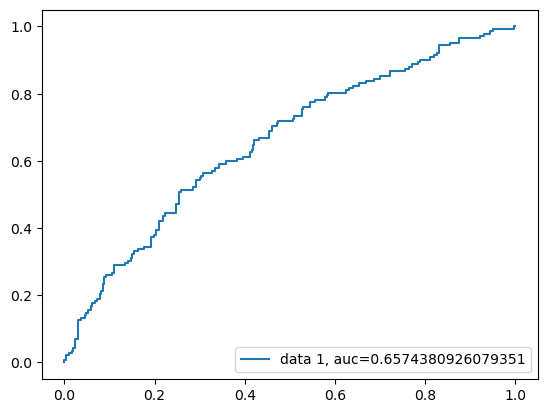

In [9]:
from sklearn import metrics
import matplotlib.pyplot as plt
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

Hyperpareameter Tunning??

Coefficient for each features

In [10]:
# feature_names = list(X_train.columns)  # Extract feature names from DataFrame
# coefficients = model.coef_.flatten()

# # Create a DataFrame to display
# coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
# print(coef_df)

Applying Statsmodels to extract feature coefficient with p-value

In [11]:
import statsmodels.api as sm

# Add intercept to feature set
X_train_with_intercept = sm.add_constant(X_train)

# Fit logistic regression model using statsmodels
logit_model = sm.Logit(y_train, X_train_with_intercept)
result = logit_model.fit()

# Display summary (includes p-values)
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.614884
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Malnurished   No. Observations:                 1791
Model:                          Logit   Df Residuals:                     1757
Method:                           MLE   Df Model:                           33
Date:                Thu, 06 Mar 2025   Pseudo R-squ.:                 0.04464
Time:                        22:11:36   Log-Likelihood:                -1101.3
converged:                       True   LL-Null:                       -1152.7
Covariance Type:            nonrobust   LLR p-value:                 4.121e-09
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.2919      0.578     -2.233      0.026      -2.

In [12]:
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

LogisticRegression()

## Feature selection techniques

SelectKBest with the chi-square test

In [ ]:

from sklearn.feature_selection import SelectKBest, chi2


# Use SelectKBest to select the top 10 features
selector = SelectKBest(chi2, k=18)
X_new = selector.fit_transform(X_train, y_train)

# Get the feature names
selected_features_chi = X_train.columns[selector.get_support()]

# Print the selected feature names
print(selected_features_chi)


Index(['Child_age', 'Mother_education', 'Wealth_index', 'BMI',
       'Children_under5', 'Total_children_ever_born', 'Father_education',
       'Health_insurance', 'Region_2', 'Region_3', 'Region_4', 'Region_6',
       'Religion_2', 'Religion_4', 'Ethnicity_4', 'Ethnicity_6', 'Ethnicity_7',
       'Ethnicity_8'],
      dtype='object')


In [23]:
model_chi = LogisticRegression()
model_chi.fit(X_train[selected_features_chi], y_train)

y_pred_chi = model_chi.predict(X_test[selected_features_chi])
pd.crosstab(y_test, y_pred_chi)

col_0,0,1
Malnurished,,
0,290,16
1,129,13


In [60]:
y_pred_chi = model_chi.predict(X_test[selected_features_chi])
pd.crosstab(y_test, y_pred_chi)
print(classification_report(y_test, y_pred_chi))

              precision    recall  f1-score   support

           0       0.69      0.95      0.80       306
           1       0.45      0.09      0.15       142

    accuracy                           0.68       448
   macro avg       0.57      0.52      0.48       448
weighted avg       0.61      0.68      0.59       448



Recursive Feature Elimination with logistic regression

In [ ]:
from sklearn.feature_selection import RFE
# Use RFE to select the top 10 features
rfe = RFE(model, n_features_to_select=18)
rfe.fit(X_train, y_train)

# Print the selected features
selected_features_rfe = X_train.columns[rfe.support_]
print(selected_features_rfe)


Index(['Child_age', 'Mother_education', 'Age_first_sex', 'BMI',
       'Mother_age_current', 'Region_2', 'Region_3', 'Region_5', 'Region_6',
       'Region_7', 'Religion_4', 'Ethnicity_2', 'Ethnicity_3', 'Ethnicity_4',
       'Ethnicity_5', 'Ethnicity_7', 'Ethnicity_8', 'Ethnicity_9'],
      dtype='object')


In [25]:
model_rfe = LogisticRegression()
model_rfe.fit(X_train[selected_features_rfe], y_train)

y_pred_rfe = model_rfe.predict(X_test[selected_features_rfe])
pd.crosstab(y_test, y_pred_rfe)

col_0,0,1
Malnurished,,
0,296,10
1,123,19


In [75]:
y_pred_rfe = model_rfe.predict(X_test[selected_features_rfe])
pd.crosstab(y_test, y_pred_rfe)
print(classification_report(y_test, y_pred_rfe))

              precision    recall  f1-score   support

           0       0.71      0.97      0.82       306
           1       0.66      0.13      0.22       142

    accuracy                           0.70       448
   macro avg       0.68      0.55      0.52       448
weighted avg       0.69      0.70      0.63       448



Stepwisse Features selection

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs_stepwise = SFS(model, 
                   k_features='best', 
                   forward=True, 
                   floating=True, 
                   scoring='accuracy', 
                   cv=5)

sfs_stepwise.fit(X_train, y_train)

# Selected features
print("Selected Features (Stepwise):", list(sfs_stepwise.k_feature_names_))


Selected Features (Stepwise): ['Child_age', 'Mother_education', 'Wealth_index', 'Place_residence', 'BMI', 'Children_under5', 'Mother_age_at_first_birth', 'Father_education', 'Region_3', 'Region_4', 'Region_7', 'Religion_3', 'Religion_4', 'Religion_5', 'Ethnicity_2', 'Ethnicity_3', 'Ethnicity_5', 'Ethnicity_10']


Religion_3 and Ethnicity_10 are perfectly correlated so Ethnicity_10 is removed

In [64]:

selected_features_stepwise = ['Child_age', 'Mother_education', 'Wealth_index', 'Place_residence', 'BMI', 'Children_under5', 'Mother_age_at_first_birth', 
                              'Father_education', 'Region_3', 'Region_4', 'Region_7', 'Religion_3', 'Religion_4', 'Religion_5', 'Ethnicity_2', 
                              'Ethnicity_3', 'Ethnicity_5']

model_stepwise = LogisticRegression()
model_stepwise.fit(X_train[selected_features_stepwise], y_train)

y_pred_stepwise = model_stepwise.predict(X_test[selected_features_stepwise])
pd.crosstab(y_test, y_pred_stepwise)

col_0,0,1
Malnurished,,
0,294,12
1,130,12


In [65]:
y_pred_stepwise = model_stepwise.predict(X_test[selected_features_stepwise])
pd.crosstab(y_test, y_pred_stepwise)
print(classification_report(y_test, y_pred_stepwise))

              precision    recall  f1-score   support

           0       0.69      0.96      0.81       306
           1       0.50      0.08      0.14       142

    accuracy                           0.68       448
   macro avg       0.60      0.52      0.48       448
weighted avg       0.63      0.68      0.60       448

